<a href="https://colab.research.google.com/github/div-yan-shu-13/ML-Lab-Sem-6/blob/main/Test_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [7]:
spambase = fetch_ucirepo(id = 94)
X = spambase.data.features
y = spambase.data.targets
df = pd.concat([spambase.data.features, spambase.data.targets], axis=1)
print("Shape: ", df.shape)
print(df.head)

Shape:  (4601, 58)
<bound method NDFrame.head of       word_freq_make  word_freq_address  word_freq_all  word_freq_3d  \
0               0.00               0.64           0.64           0.0   
1               0.21               0.28           0.50           0.0   
2               0.06               0.00           0.71           0.0   
3               0.00               0.00           0.00           0.0   
4               0.00               0.00           0.00           0.0   
...              ...                ...            ...           ...   
4596            0.31               0.00           0.62           0.0   
4597            0.00               0.00           0.00           0.0   
4598            0.30               0.00           0.30           0.0   
4599            0.96               0.00           0.00           0.0   
4600            0.00               0.00           0.65           0.0   

      word_freq_our  word_freq_over  word_freq_remove  word_freq_internet  \
0        

In [8]:
print("Null Values: ", df.isnull().sum().sum())
df.dropna(inplace=True)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Null Values:  0


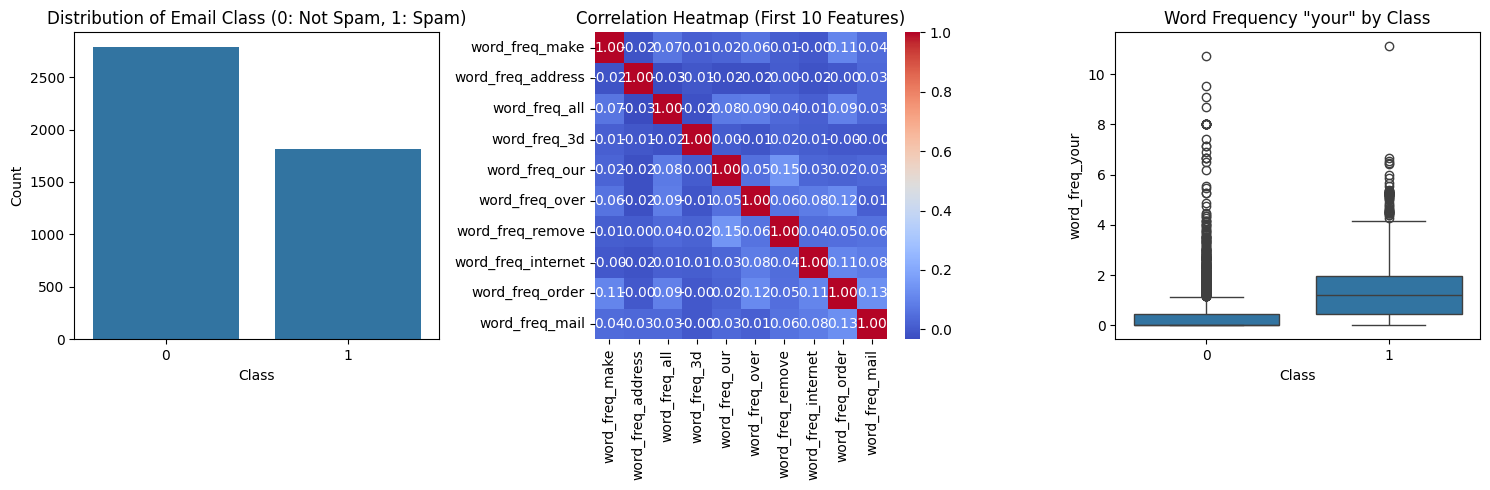

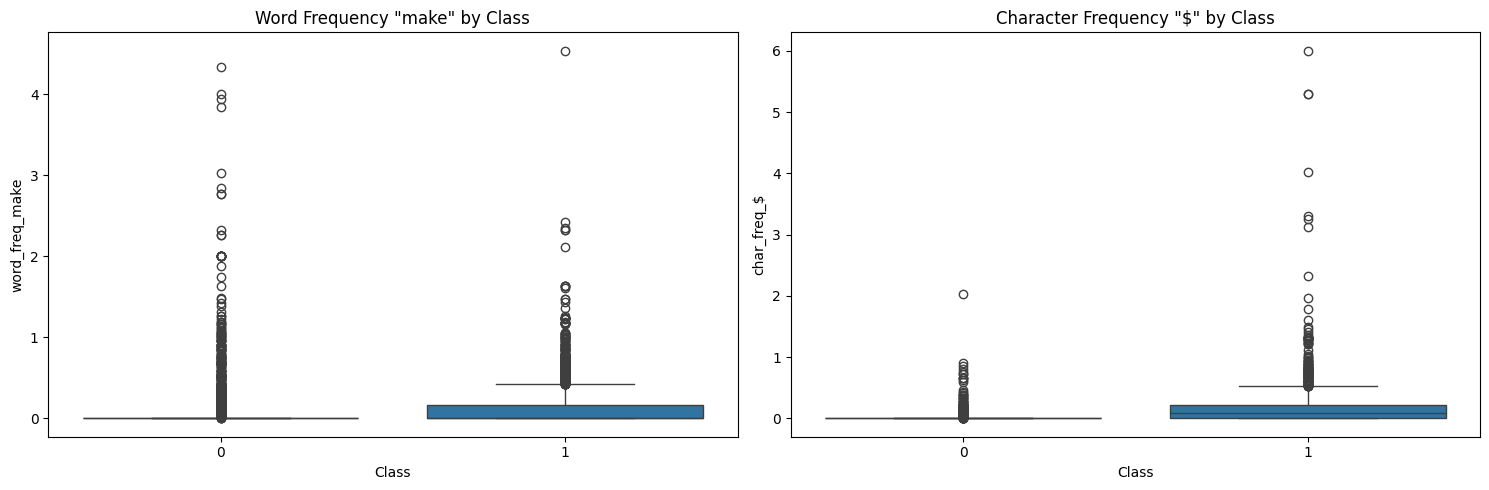

In [10]:
plt.figure(figsize=(15, 5))

# Visualization 1: Distribution of 'Class' (Spam or Not Spam)
plt.subplot(1, 3, 1)
sns.countplot(x='Class', data=df)
plt.title('Distribution of Email Class (0: Not Spam, 1: Spam)')
plt.xlabel('Class')
plt.ylabel('Count')

# Visualization 2: Correlation Heatmap for first 10 features
plt.subplot(1, 3, 2)
correlation_matrix = df.iloc[:, :10].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (First 10 Features)')

# Visualization 3: Box plots for selected features by Class
plt.subplot(1, 3, 3)
sns.boxplot(x='Class', y='word_freq_your', data=df)
plt.title('Word Frequency "your" by Class')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Class', y='word_freq_make', data=df)
plt.title('Word Frequency "make" by Class')

plt.subplot(1, 2, 2)
sns.boxplot(x='Class', y='char_freq_$', data=df)
plt.title('Character Frequency "$" by Class')

plt.tight_layout()
plt.show()

In [11]:
dt = DecisionTreeClassifier(criterion="gini", max_depth=5, random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred = dt.predict(X_test_scaled)

In [12]:
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Classification Report: ")
print(classification_report(y_test, y_pred, target_names=['Not Spam', 'Spam']))


Accuracy:  0.8990228013029316
Classification Report: 
              precision    recall  f1-score   support

    Not Spam       0.89      0.94      0.92       558
        Spam       0.91      0.83      0.87       363

    accuracy                           0.90       921
   macro avg       0.90      0.89      0.89       921
weighted avg       0.90      0.90      0.90       921



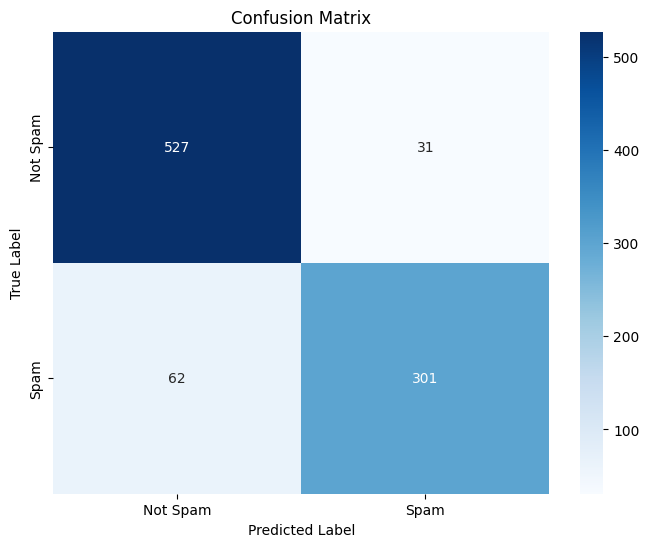

In [13]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Spam', 'Spam'], yticklabels=['Not Spam', 'Spam'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()